# 06 — ELF and LOL analysis

Compare ELF/LOL cube statistics, voxel distributions, central slices, and percentile summaries for parent and terminal-functionalized PDI.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Make figures independent of PyCharm/Jupyter dark-theme defaults.
plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "savefig.facecolor": "white",
        "savefig.edgecolor": "white",
        "text.color": "black",
        "axes.labelcolor": "black",
        "axes.edgecolor": "black",
        "xtick.color": "black",
        "ytick.color": "black",
    }
)


def style_white_axes(fig, ax):
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")
    ax.tick_params(colors="black")
    ax.xaxis.label.set_color("black")
    ax.yaxis.label.set_color("black")
    ax.title.set_color("black")
    for spine in ax.spines.values():
        spine.set_edgecolor("black")
    legend = ax.get_legend()
    if legend is not None:
        for text in legend.get_texts():
            text.set_color("black")


def style_white_colorbar(colorbar):
    colorbar.ax.set_facecolor("white")
    colorbar.ax.tick_params(colors="black")
    colorbar.ax.yaxis.label.set_color("black")
    colorbar.outline.set_edgecolor("black")
    for spine in colorbar.ax.spines.values():
        spine.set_edgecolor("black")

ROOT = Path("..").resolve()
RESULTS = ROOT / "results" / "ground_state"
FIGURES = ROOT / "figures"
SYSTEM_ORDER = ["pdi", "pdi_terminal_functionalized"]
SYSTEM_LABELS = {
    "pdi": "Parent PDI",
    "pdi_terminal_functionalized": "Terminal-functionalized PDI",
}
SYSTEM_COLORS = {
    "pdi": "#0018F9",
    "pdi_terminal_functionalized": "#F28500",
}

In [2]:
cube_metadata = pd.read_csv(RESULTS / "cubes" / "cube_metadata.csv")
elf_lol = cube_metadata[cube_metadata["cube_type"].isin(["elf", "lol"])].copy()

ELF_LOL_FIGURES = FIGURES / "elf_lol"
ELF_LOL_FIGURES.mkdir(parents=True, exist_ok=True)


def resolve_source_file(source_file: str) -> Path:
    source_path = ROOT / source_file
    if source_path.is_file():
        return source_path

    parts = Path(source_file).parts
    if "multiwfn_analysis" in parts and "ground_state" not in parts:
        index = parts.index("multiwfn_analysis")
        candidate = ROOT / Path(
            *parts[: index + 1],
            "ground_state",
            *parts[index + 1 :],
        )
        if candidate.is_file():
            return candidate

    raise FileNotFoundError(
        f"Could not resolve cube source file {source_file!r}. "
        "Check cube_metadata.csv or rerun scripts.postprocess.parse_cube."
    )


elf_lol["resolved_source_file"] = [
    str(resolve_source_file(source_file).relative_to(ROOT))
    for source_file in elf_lol["source_file"]
]

elf_lol


,system,cube_type,source_file,comment_1,comment_2,atom_count,origin_x,origin_y,origin_z,nx,...,maximum,mean,standard_deviation,integral,absolute_integral,positive_voxel_fraction,negative_voxel_fraction,zero_voxel_fraction,sha256,resolved_source_file
0,pdi,elf,calculations/pdi/multiwfn_analysis/elf_lol/pdi...,Generated by Multiwfn,Totally 530640 grid points,40,-18.592701,-12.401697,-6.071426,134,...,0.999945,0.091723,0.213142,1064.260298,1064.260298,1.0,0.0,0.0,cfed0707e4c8eae3f264ae9f24fb4560f703d05a580625...,calculations/pdi/multiwfn_analysis/ground_stat...
1,pdi,lol,calculations/pdi/multiwfn_analysis/elf_lol/pdi...,Generated by Multiwfn,Totally 530640 grid points,40,-18.592701,-12.401697,-6.071426,134,...,0.932704,0.054950,0.120178,637.581392,637.581392,1.0,0.0,0.0,a81e180d950713781ffb3065316564cc731608ce7550a1...,calculations/pdi/multiwfn_analysis/ground_stat...
6,pdi_terminal_functionalized,elf,calculations/pdi_terminal_functionalized/multi...,Generated by Multiwfn,Totally 530640 grid points,70,-22.736951,-12.429803,-12.935938,120,...,0.999927,0.061610,0.189609,1810.221830,1810.221830,1.0,0.0,0.0,7a7b17c1145b4d84f40971db3ea128dc5ca98f8bdd2a18...,calculations/pdi_terminal_functionalized/multi...
7,pdi_terminal_functionalized,lol,calculations/pdi_terminal_functionalized/multi...,Generated by Multiwfn,Totally 530640 grid points,70,-22.736951,-12.429803,-12.935938,120,...,0.967875,0.033569,0.097876,986.317614,986.317614,1.0,0.0,0.0,77273529b9597fc504a7a041d09bc53b9e5a04fed6fbff...,calculations/pdi_terminal_functionalized/multi...


In [3]:
expected = pd.MultiIndex.from_product(
    [SYSTEM_ORDER, ["elf", "lol"]],
    names=["system", "cube_type"],
)
observed = pd.MultiIndex.from_frame(elf_lol[["system", "cube_type"]])
missing = expected.difference(observed)

assert len(missing) == 0, f"Missing cubes: {list(missing)}"

elf_lol.groupby(["system", "cube_type"])[
    ["minimum", "maximum", "mean", "standard_deviation", "absolute_integral"]
].first()


minimum   maximum      mean  \
system                      cube_type                                     
pdi                         elf        4.237460e-60  0.999945  0.091723   
                            lol        5.571930e-15  0.932704  0.054950   
pdi_terminal_functionalized elf        5.347820e-75  0.999927  0.061610   
                            lol        4.920660e-18  0.967875  0.033569   

                                       standard_deviation  absolute_integral  
system                      cube_type                                         
pdi                         elf                  0.213142        1064.260298  
                            lol                  0.120178         637.581392  
pdi_terminal_functionalized elf                  0.189609        1810.221830  
                            lol                  0.097876         986.317614

In [4]:
def parse_cube_float(value: str) -> float:
    return float(value.replace("D", "E"))


def read_cube(path: Path) -> dict[str, object]:
    with path.open("r", encoding="utf-8", errors="replace") as handle:
        comment_1 = handle.readline().rstrip()
        comment_2 = handle.readline().rstrip()
        header = handle.readline().split()

        if len(header) < 4:
            raise ValueError(f"Malformed cube header in {path}")

        signed_atom_count = int(header[0])
        atom_count = abs(signed_atom_count)
        origin = np.array([parse_cube_float(value) for value in header[1:4]])

        dimensions = []
        axes = []
        for _ in range(3):
            fields = handle.readline().split()
            dimensions.append(abs(int(fields[0])))
            axes.append([parse_cube_float(value) for value in fields[1:4]])

        atoms = []
        for atom_index in range(1, atom_count + 1):
            fields = handle.readline().split()
            atoms.append(
                {
                    "atom": atom_index,
                    "atomic_number": int(float(fields[0])),
                    "charge": parse_cube_float(fields[1]),
                    "x": parse_cube_float(fields[2]),
                    "y": parse_cube_float(fields[3]),
                    "z": parse_cube_float(fields[4]),
                }
            )

        if signed_atom_count < 0:
            fields = handle.readline().split()
            orbital_count = int(fields[0])
            consumed = len(fields) - 1
            while consumed < orbital_count:
                consumed += len(handle.readline().split())

        values = np.fromiter(
            (
                parse_cube_float(token)
                for line in handle
                for token in line.split()
            ),
            dtype=float,
        )

    expected_values = int(np.prod(dimensions))
    if values.size != expected_values:
        raise ValueError(f"{path}: expected {expected_values}, got {values.size}")

    return {
        "comment_1": comment_1,
        "comment_2": comment_2,
        "origin": origin,
        "dimensions": tuple(dimensions),
        "axes": np.array(axes),
        "atoms": pd.DataFrame(atoms),
        "grid": values.reshape(tuple(dimensions)),
    }


records = {}
for row in elf_lol.itertuples(index=False):
    cube_path = ROOT / row.resolved_source_file
    records[(row.system, row.cube_type)] = read_cube(cube_path)

{key: value["grid"].shape for key, value in records.items()}


{('pdi', 'elf'): (134, 90, 44),
 ('pdi', 'lol'): (134, 90, 44),
 ('pdi_terminal_functionalized', 'elf'): (120, 66, 67),
 ('pdi_terminal_functionalized', 'lol'): (120, 66, 67)}

In [5]:
# Quantitative voxel-distribution helpers.
def finite_grid_values(system: str, cube_type: str) -> np.ndarray:
    values = records[(system, cube_type)]["grid"].ravel()
    return values[np.isfinite(values)]


def save_elf_lol_figure(fig, stem: str) -> None:
    fig.savefig(ELF_LOL_FIGURES / f"{stem}.pdf", bbox_inches="tight")
    fig.savefig(ELF_LOL_FIGURES / f"{stem}.png", dpi=300, bbox_inches="tight")


def style_distribution_axis(fig, ax) -> None:
    ax.spines[["top", "right"]].set_visible(False)
    style_white_axes(fig, ax)


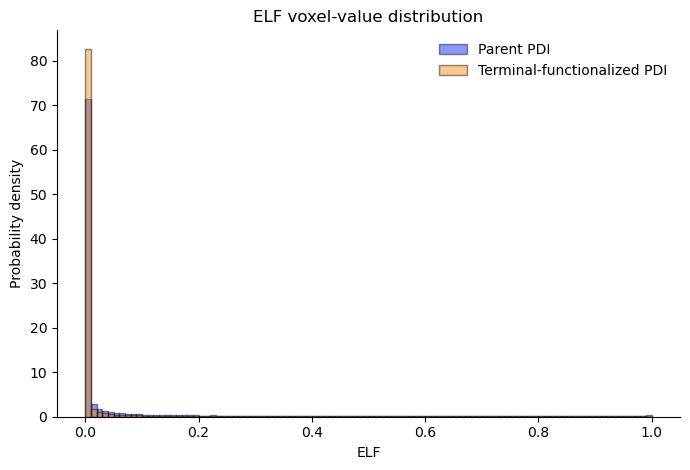

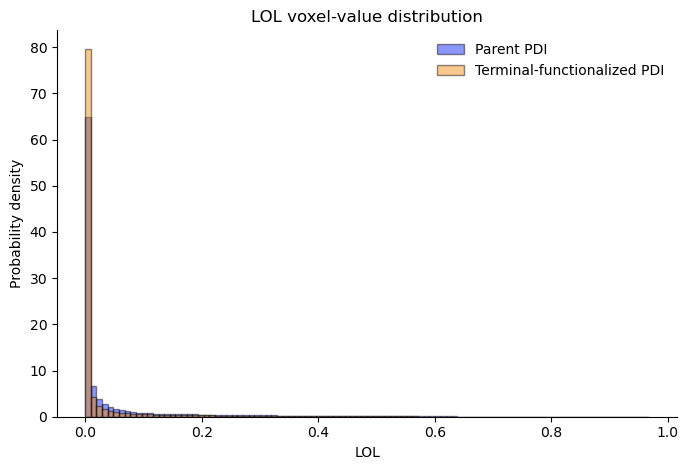

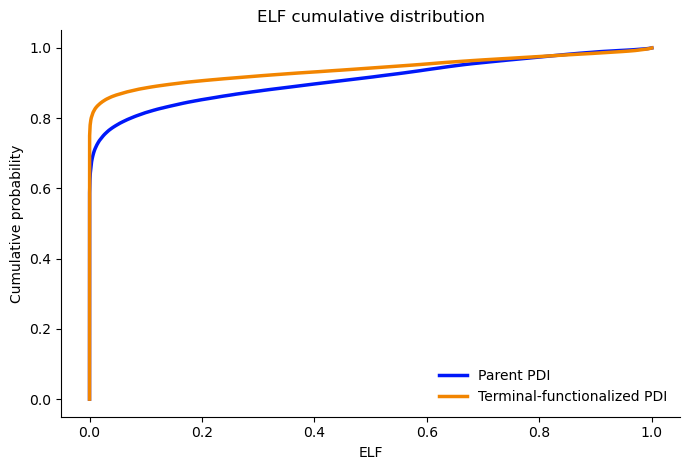

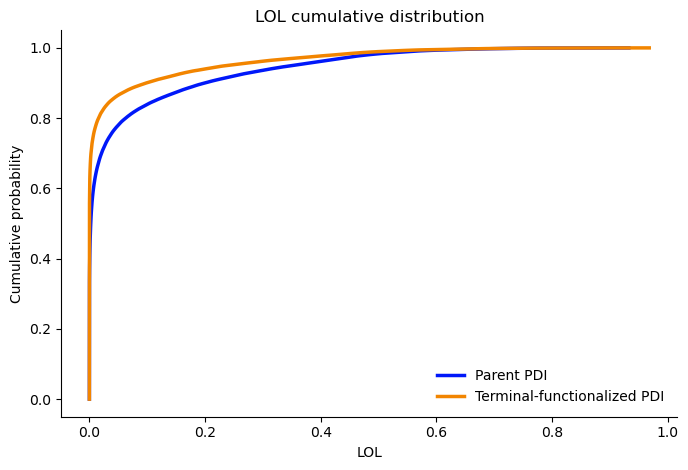

In [6]:
# Normalized voxel-value histograms.
for quantity in ["elf", "lol"]:
    values_by_system = {
        system: finite_grid_values(system, quantity)
        for system in SYSTEM_ORDER
    }
    combined_values = np.concatenate(list(values_by_system.values()))
    bin_edges = np.linspace(
        float(np.nanmin(combined_values)),
        float(np.nanmax(combined_values)),
        101,
    )

    fig, ax = plt.subplots(facecolor="white", figsize=(7.0, 4.8))

    for system in SYSTEM_ORDER:
        ax.hist(
            values_by_system[system],
            bins=bin_edges,
            density=True,
            color=SYSTEM_COLORS[system],
            alpha=0.45,
            edgecolor="black",
            label=SYSTEM_LABELS[system],
        )

    ax.set_xlabel(quantity.upper())
    ax.set_ylabel("Probability density")
    ax.set_title(f"{quantity.upper()} voxel-value distribution")
    ax.legend(frameon=False)
    style_distribution_axis(fig, ax)

    fig.tight_layout()
    #save_elf_lol_figure(fig, f"{quantity}_histogram")
    plt.show()


# Empirical cumulative voxel-value distributions.
for quantity in ["elf", "lol"]:
    fig, ax = plt.subplots(facecolor="white", figsize=(7.0, 4.8))

    for system in SYSTEM_ORDER:
        values = np.sort(finite_grid_values(system, quantity))
        cumulative_probability = np.arange(1, len(values) + 1, dtype=float) / len(values)

        ax.plot(
            values,
            cumulative_probability,
            color=SYSTEM_COLORS[system],
            linewidth=2.5,
            label=SYSTEM_LABELS[system],
        )

    ax.set_xlabel(quantity.upper())
    ax.set_ylabel("Cumulative probability")
    ax.set_title(f"{quantity.upper()} cumulative distribution")
    ax.legend(frameon=False)
    style_distribution_axis(fig, ax)

    fig.tight_layout()
    #save_elf_lol_figure(fig, f"{quantity}_cdf")
    plt.show()


In [7]:
# Tidy voxel percentile and summary-statistic table.
percentile_definitions = [
    ("minimum", 0),
    ("1st percentile", 1),
    ("5th percentile", 5),
    ("10th percentile", 10),
    ("25th percentile", 25),
    ("median", 50),
    ("75th percentile", 75),
    ("90th percentile", 90),
    ("95th percentile", 95),
    ("99th percentile", 99),
    ("maximum", 100),
]

percentile_rows = []

for system in SYSTEM_ORDER:
    for quantity in ["elf", "lol"]:
        values = finite_grid_values(system, quantity)

        for statistic, percentile in percentile_definitions:
            percentile_rows.append(
                {
                    "system": system,
                    "cube_type": quantity,
                    "statistic": statistic,
                    "value": float(np.percentile(values, percentile)),
                }
            )

        percentile_rows.extend(
            [
                {
                    "system": system,
                    "cube_type": quantity,
                    "statistic": "mean",
                    "value": float(np.mean(values)),
                },
                {
                    "system": system,
                    "cube_type": quantity,
                    "statistic": "standard deviation",
                    "value": float(np.std(values)),
                },
            ]
        )

elf_lol_percentiles = pd.DataFrame(percentile_rows)
elf_lol_percentiles.to_csv(
    RESULTS / "cubes" / "elf_lol_percentiles.csv",
    index=False,
)

display(elf_lol_percentiles)

percentile_publication_tables = {}
for quantity in ["elf", "lol"]:
    publication_table = elf_lol_percentiles[
        elf_lol_percentiles["cube_type"] == quantity
    ].pivot(
        index="statistic",
        columns="system",
        values="value",
    )
    publication_table = publication_table[[system for system in SYSTEM_ORDER]]
    publication_table.columns = [SYSTEM_LABELS[system] for system in publication_table.columns]
    percentile_publication_tables[quantity] = publication_table

    display(publication_table)


,system,cube_type,statistic,value
0,pdi,elf,minimum,4.237460e-60
1,pdi,elf,1st percentile,3.001765e-43
2,pdi,elf,5th percentile,1.036443e-30
3,pdi,elf,10th percentile,4.041077e-23
4,pdi,elf,25th percentile,1.452338e-13
5,pdi,elf,median,4.715365e-06
6,pdi,elf,75th percentile,2.454227e-02
7,pdi,elf,90th percentile,4.137486e-01
8,pdi,elf,95th percentile,6.542037e-01
9,pdi,elf,99th percentile,9.152798e-01


,Parent PDI,Terminal-functionalized PDI
statistic,,
10th percentile,4.041077e-23,9.474393e-36
1st percentile,3.001765e-43,3.849412e-52
25th percentile,1.452338e-13,1.383370e-24
5th percentile,1.036443e-30,8.286070e-42
75th percentile,2.454227e-02,1.943068e-04
90th percentile,4.137486e-01,1.610632e-01
95th percentile,6.542037e-01,5.650703e-01
99th percentile,9.152798e-01,9.505545e-01
maximum,9.999450e-01,9.999270e-01


,Parent PDI,Terminal-functionalized PDI
statistic,,
10th percentile,2.821501e-07,7.004409e-10
1st percentile,1.685659e-11,2.574624e-13
25th percentile,4.030483e-05,1.687885e-07
5th percentile,6.742256e-09,3.709419e-11
75th percentile,3.570297e-02,6.772290e-03
90th percentile,1.991461e-01,9.807141e-02
95th percentile,3.515735e-01,2.372580e-01
99th percentile,5.543200e-01,5.063641e-01
maximum,9.327040e-01,9.678750e-01


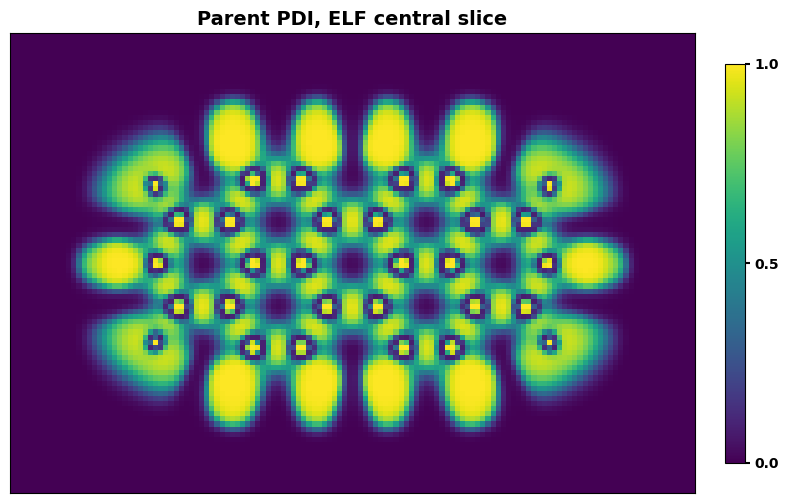

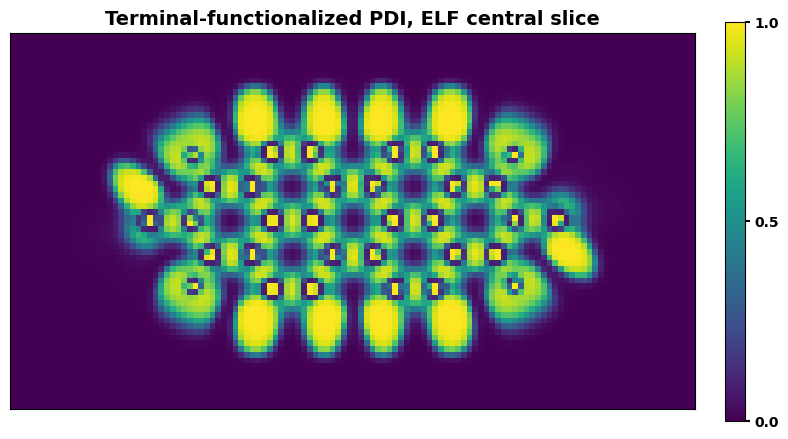

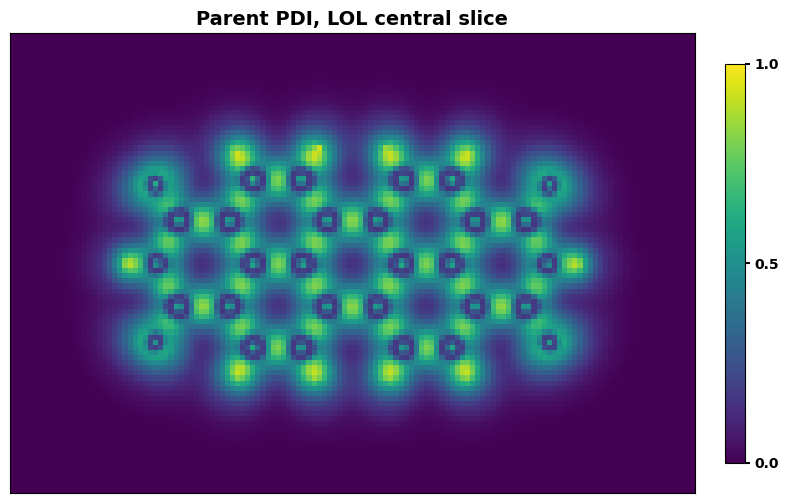

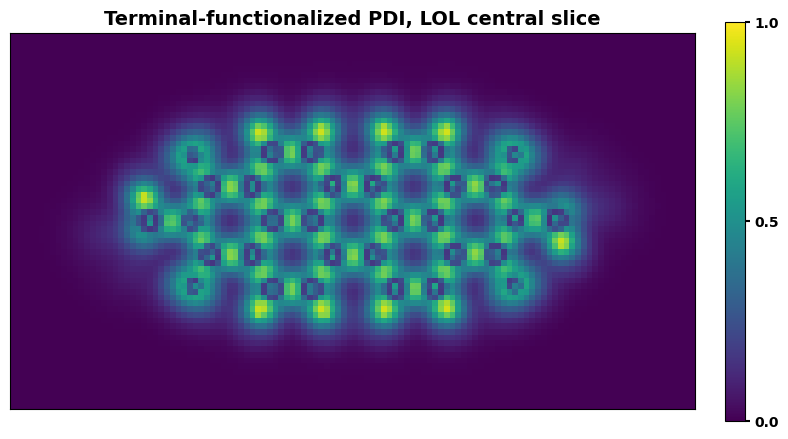

In [13]:
for quantity in ["elf", "lol"]:
    quantity_records = [records[(system, quantity)] for system in SYSTEM_ORDER]
    vmin = 0.0
    vmax = 1.0

    for system in SYSTEM_ORDER:
        record = records[(system, quantity)]
        grid = record["grid"]
        z_index = grid.shape[2] // 2
        data = grid[:, :, z_index]

        fig, ax = plt.subplots(facecolor="white", figsize=(8, 6))
        image = ax.imshow(
            data.T,
            origin="lower",
            aspect="equal",
            interpolation="nearest",
            vmin=vmin,
            vmax=vmax,
        )
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.set_title(
            f"{SYSTEM_LABELS[system]}, {quantity.upper()} central slice",
            #f"(index {z_index})",
            fontsize=14, fontweight="bold"
        )

        colorbar = fig.colorbar(
            image,
            ax=ax,
            fraction=0.04,
            pad=0.04,
            shrink=0.7,
        )

        # No colorbar label
        # colorbar.set_label(quantity.upper())

        # Tick settings
        colorbar.ax.tick_params(labelsize=10, width=1.5)
        colorbar.set_ticks([0.0, 0.5, 1.0])

        # Tick weight
        for tick in colorbar.ax.get_yticklabels():
            tick.set_fontsize(10)
            tick.set_fontweight("bold")

        # Remove image ticks
        ax.set_xticks([])
        ax.set_yticks([])

        style_white_axes(fig, ax)
        style_white_colorbar(colorbar)

        fig.tight_layout()
        fig.savefig(
            ELF_LOL_FIGURES / f"{system}_{quantity}_central_slice.pdf",
            bbox_inches="tight",
        )
        fig.savefig(
            ELF_LOL_FIGURES / f"{system}_{quantity}_central_slice.png",
            dpi=300,
            bbox_inches="tight",
        )
        plt.show()


In [9]:
"summary = elf_lol[
        "system",
        "cube_type",
        "source_file",
        "resolved_source_file",
        "minimum",
        "maximum",
        "mean",
        "standard_deviation",
        "integral",
        "absolute_integral",
        "positive_voxel_fraction",
        "negative_voxel_fraction",
    ]
].copy()

summary.to_csv(RESULTS / "cubes" / "elf_lol_summary.csv", index=False)
summary


SyntaxError: unterminated string literal (detected at line 1) (2305668938.py, line 1)